# Attribute 8 - Buffer contribution: existing area buffer

### Data layers
Proximity to ENA (maps of realms created by Eco-index)/ shape optimisation model (using Convex Hulls in GIS – David to generate internally)
DOC EMU link 

### Scoring

- 10 `<=20m from a DoC EMU`
- 8  `<=20m from other DoC Reserve`
- 6  `<=20m from QEII covenant`
- 4  ~`<=20m from any other ENA within the same recon area ie. an under represented ecosystem`~
- 2  ~`<=20m from any other existing Natural Area outside of the reconstruction envelope`~
- 0  ~`Otherwise`~



In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import json
import math
import os
from os import listdir

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from constants import small_polygon_threshold, m2_to_ha, x_resolution, y_resolution, keep_cols, keep_cols_catch

# Load

In [5]:
%%time
protected = gpd.read_file("../BaseLayersExternal/lds-protected-areas-GPKG_downloaded_20240522/protected-areas.gpkg")
protected = protected.to_crs('epsg:2193')
protected.sindex

qe = gpd.read_file(r"../BaseLayersExternal/QEII/QEII_OSCovenants_20240627/QEII_OSCovenants_20240627.shp")
qe = qe.to_crs('epsg:2193')
qe.sindex

doc = gpd.read_file("../BaseLayersExternal/DOC_Ecosystem_Management_Units/DOC_Ecosystems_Management_Units_169624429036746831.gpkg")
doc = doc.to_crs('epsg:2193')
doc.sindex

buffer_size = 20

CPU times: total: 922 ms
Wall time: 947 ms


In [6]:
%%time
# Area of Interest
aoi = gpd.read_file("../BaseLayersEco-index/Eco-index_RestorableAreas__Catchments_v290824.gpkg")
aoi = aoi[['Catchment', 'geometry']].copy()
aoi.sindex
aoi.shape

CPU times: total: 922 ms
Wall time: 927 ms


(29431, 2)

#### PixelScore 10

In [7]:
%%time

def get_buffer_pixelscore_10(aoi, doc_df):
    # Select only doc reserves in area of interest 
    doc_filtered = gpd.sjoin(doc_df, aoi, how="inner", predicate="intersects")
    doc_filtered.sindex

    # Generate buffer around the area
    buffer10 = doc_filtered.copy()
    buffer10['geometry'] = buffer10.buffer(buffer_size, resolution=4)
    buffer10 = doc_filtered.overlay(buffer10, how='symmetric_difference', keep_geom_type=True)
    buffer10 = buffer10.dissolve().explode()
    buffer10 = buffer10[['geometry']].reset_index()
    return buffer10
    
buffer10 = get_buffer_pixelscore_10(aoi, doc)

CPU times: total: 59min 50s
Wall time: 59min 54s


#### PixelScore 8

In [8]:
%%time

def get_buffer_pixelscore_08(aoi, protected_df):
    reserve_types = ['National Park', 'Wildlife Area', 'Conservation Area', 'Reserve']

    protected = protected_df[protected_df['type'].isin(reserve_types)].copy()
    protected.sindex
    # Get Area of Interest 
    protected_08 = gpd.sjoin(protected, aoi, how="inner", predicate="intersects")

    # # Flatten ### needed to prevent:
    # # TopologyException: found non-noded intersection between LINESTRING (1.57728e+06 5.3354e+06, 1.57728e+06 5.3354e+06) and LINESTRING (1.57729e+06 5.33538e+06, 1.57728e+06 5.3354e+06) 
    protected_08 = protected_08[['geometry']].dissolve().explode() ## Not ACTUALLY needed, this is removed by the symmetric diference later but code doesn't run without it
    
    # #Create buffer area
    buffer08 = protected_08.copy()
    buffer08['geometry'] = buffer08.buffer(buffer_size, resolution=4)

    # Remove the reserve area (just want the buffer area or 'donut' around the reserve)
    buffer08 = buffer08.overlay(protected_08, how='symmetric_difference', keep_geom_type=True)
    return buffer08

buffer08 = get_buffer_pixelscore_08(aoi, protected)

CPU times: total: 28min 29s
Wall time: 28min 30s


#### PixelScore 6

In [9]:
%%time

def get_buffer_pixelscore_06(aoi, qe,):
    qe_filtered = gpd.sjoin(qe, aoi, how="inner", predicate="intersects")
    qe_filtered = qe_filtered[qe_filtered['Type']=='Open Space Covenant'].copy()
    qe_filtered.sindex

    # Buffer
    buffer06 = qe_filtered.copy()
    buffer06['geometry'] = buffer06.buffer(buffer_size, resolution=5) 
    buffer06.sindex

    # Remove reserve
    buffer06 = qe_filtered.overlay(buffer06, how='symmetric_difference', keep_geom_type=True)
    buffer06 = buffer06.dissolve().explode(index_parts=False)
    buffer06 = buffer06[['geometry']].copy()
    return buffer06

buffer06 = get_buffer_pixelscore_06(aoi, qe)

CPU times: total: 1min 5s
Wall time: 1min 5s


#### Combine

In [10]:
%%time
buffer_dfs = [buffer10,
              buffer08,
              buffer06,
              # buffer04,
              ]

pixel_scores = [10, 8, 6,
                # 4
               ]
pixel_descs = [
    '<=20m from a DOC EMU',
    '<=20m from a reserve that is not a DOC EMU',
    '<=20m from QEII covenant',
    # '<=20m from any other ENA'
]

buffer_dfs_clean = []
start_ind = []

for df, pixel_score, pixel_desc in zip(buffer_dfs, pixel_scores, pixel_descs):
    buffer_df = df.copy()
    buffer_df.sindex
    print('\n', pixel_score, pixel_desc)
    print(buffer_df.shape[0])
    print(buffer_df.crs, aoi.crs)
    buffer_df['PixelScore'] = pixel_score
    buffer_df['PixelDesc'] = pixel_desc
    buffer_df['Attribute'] = 'Protective Buffer'
    buffer_df = (buffer_df[['PixelScore', 'PixelDesc', 'Attribute', 'geometry']]
                 .overlay(aoi[['geometry']], how='intersection', keep_geom_type=True))
    buffer_dfs_clean.append(buffer_df)
    
# buffer10clean, buffer08clean, buffer06clean, buffer04clean = 

overlapping = gpd.GeoDataFrame(pd.concat(buffer_dfs_clean, axis=0, ignore_index=True))


 10 <=20m from a DOC EMU
7113
EPSG:2193 EPSG:2193

 8 <=20m from a reserve that is not a DOC EMU
15642
EPSG:2193 EPSG:2193

 6 <=20m from QEII covenant
5456
EPSG:2193 EPSG:2193
CPU times: total: 4min 56s
Wall time: 4min 56s


In [14]:
overlapping.to_file("../OutputArtifacts/A08_ProtectiveBuffer/A08_IntermediateLayers/overlapping_20240827.gpkg")

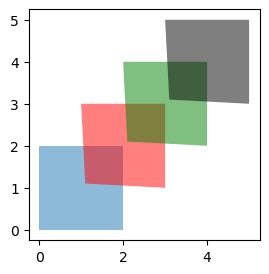

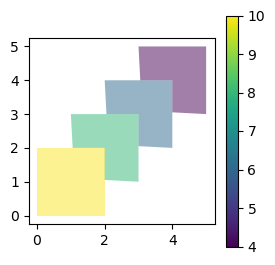

In [13]:
from gis_analysis_functions import priority_stack_n_layers
from shapely.geometry import Polygon

pixel_scores = [10, 8, 6, 4, 2]

gdf1 = gpd.GeoDataFrame({'geometry': gpd.GeoSeries([Polygon([(0,0), (2,0), (2,2), (0,2)])]), 'PixelScore': pixel_scores[:1]})
gdf2 = gpd.GeoDataFrame({'geometry': gpd.GeoSeries([Polygon([(1.1,1.1), (3,1), (3,3), (1,3)])]), 'PixelScore': pixel_scores[1:2]})
gdf3 = gpd.GeoDataFrame({'geometry': gpd.GeoSeries([Polygon([(2.1,2.1), (4,2), (4,4), (2,4)])]), 'PixelScore': pixel_scores[2:3]})
gdf4 = gpd.GeoDataFrame({'geometry': gpd.GeoSeries([Polygon([(3.1,3.1), (5,3), (5,5), (3,5)])]), 'PixelScore': pixel_scores[3:4]})

gdf_comb = priority_stack_n_layers([gdf1, gdf2, gdf3, gdf4])

fig, ax = plt.subplots(figsize=(3,3))
gdf1.plot(ax=ax, legend=True, alpha=.5)
gdf2.plot(ax=ax, legend=True, color = 'r', alpha=.5)
gdf3.plot(ax=ax, legend=True, color = 'g', alpha=.5)
gdf4.plot(ax=ax, legend=True, color = 'black', alpha=.5)
plt.show()

fig, ax = plt.subplots(figsize=(3,3))
gdf_comb.plot(ax=ax, column='PixelScore', legend=True, alpha=.5)
plt.show()

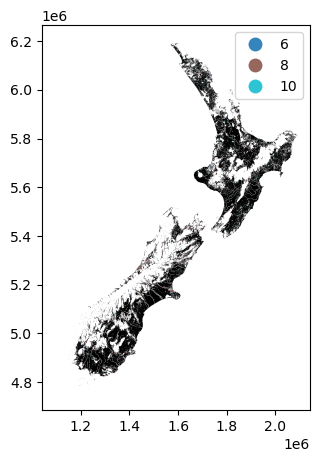

In [16]:
gdf_comb = priority_stack_n_layers(buffer_dfs_clean)

fig, ax = plt.subplots(figsize=(12,5))
aoi.plot(ax=ax, color='black')
gdf_comb.plot(column='PixelScore', categorical=True, ax=ax, legend=True, alpha=.9)
# ana.plot(ax=ax, color='yellow')
plt.show()

In [17]:
gdf_comb.to_file("../OutputArtifacts/A08_ProtectiveBuffer/A08_IntermediateLayers/stacked_20240827.gpkg")

ana = gpd.read_file('output_layers/attr07/ana_dissolved_explode_202400708.gpkg')
# Filter to areas close to natural areas
Karen: Have realised we used all reserves not just DOC reserves, which picks up eg race tracks, gravel reserves that dont need to be buffered.
We either need to limit to DOC reserves (but still might pick up eg grazing leases) or better filter out all pixels that arent within 20 m of an ENA - so its only areas of native veg within reserves that we generate buffers for


In [19]:
%%time
catch = gpd.read_file("../BaseLayersEco-index/Eco-index_Catchments_v080623.gpkg")
catch = catch.to_crs('epsg:2193')
catch.sindex


ana = gpd.read_file("../OutputArtifacts/A03_NativeVegetationProximity/A03_IntermediateLayers/ena_aoi_bigger_20240829.gpkg")
ana.sindex

CPU times: total: 2.67 s
Wall time: 2.67 s


,LandCoverStatus,Realm,Catchment,geometry
0,Regenerating,Terrestrial,Three Knights,"MULTIPOLYGON (((1511221.152 6216372.95, 151122..."
1,Mature,Freshwater,Tasman Bay,"MULTIPOLYGON (((1599954.209 5475349.74, 159995..."
2,Mature,Freshwater,Selwyn-Avon,"MULTIPOLYGON (((1575940.22 5177002.043, 157594..."
3,Mature,Freshwater,Tasman Bay,"MULTIPOLYGON (((1599736.703 5475718.378, 15997..."
4,Mature,Freshwater,Ōpōtiki,"MULTIPOLYGON (((1962921.193 5781744.855, 19629..."
...,...,...,...,...
238063,Regenerating,Terrestrial,Tukituki,"MULTIPOLYGON (((1929247.747 5577083.52, 192921..."
238064,Regenerating,Terrestrial,Mōkau-Kāwhia-Raglan,"MULTIPOLYGON (((1778368.882 5824960.091, 17783..."
238065,Regenerating,Terrestrial,Wairoa North,"MULTIPOLYGON (((1664255.394 6056618.646, 16642..."
238066,Mature,Terrestrial,Tasman Bay,"MULTIPOLYGON (((1607549.952 5432565.767, 16075..."


In [ ]:
# %%time
# ana_buffer = ana.copy()
# ana_buffer.sindex
# ana_buffer['geometry'] = ana_buffer.buffer(buffer_size) 

# ana_buffer = ana_buffer.overlay(aoi[['geometry']], how='intersection')
# ana_buffer.sindex
# # ana_buffer.to_file("output_layers/attr08/08_ana_buffer_20240709.gpkg")


In [20]:
ana_buffer = gpd.read_file("../OutputArtifacts/A03_NativeVegetationProximity/A03_IntermediateLayers/ena_aoi_bigger_20240829.gpkg")
ana_buffer['geometry'] = ana_buffer.buffer(buffer_size) 

In [21]:
%%time
gdf_comb.sindex
gdf_comb_ana = gdf_comb.overlay(ana_buffer[['geometry']])


CPU times: total: 1min 58s
Wall time: 1min 58s


C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 1101 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


In [22]:
gdf_comb_ana = gdf_comb_ana.rename({'Attribute': 'PrioOption'}, axis=1)

In [23]:
gdf_comb_ana.PixelDesc.value_counts()

PixelDesc
<=20m from a reserve that is not a DOC EMU    25995
<=20m from QEII covenant                       9489
<=20m from a DOC EMU                           6120
Name: count, dtype: int64

In [26]:
final = gdf_comb_ana.overlay(aoi)

C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 13969 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


In [28]:
%%time
final['Area_ha'] = final.area * m2_to_ha
final = final[final['Area_ha'] > small_polygon_threshold].reset_index(drop=True)
final['Area_ha'] = final['Area_ha'].round(2)

# # Shape
final.loc[final.PixelScore==8, 'PixelDesc' ]= '<=20m from a reserve that is not a DOC EMU'
final[keep_cols_catch].to_file("../OutputArtifacts/A08_ProtectiveBuffer/A08_ProtectiveBuffer_20240828.gpkg")